# Calibrate a Dakis X pulse on real IQM hardware

Adapted from `Rabi_calib_detune_SX_exp.ipynb`, for a full X (pi) pulse instead of SX
(pi/2), starting from `Results/Pulses/pulse_fields_X_cfg0039.json`.

**This notebook submits real jobs to IQM hardware and consumes real shot budget.**
Every cell below `## Connect to IQM hardware` talks to a live server. Read through and
adjust parameters (server URL, qubit, amplitude scan ranges) before running anything.

Requires the same `IQM_TOKEN` environment variable and packages as the SX notebook.


In [1]:
import os, json, glob
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

from qiskit import QuantumCircuit

from iqm.qiskit_iqm import IQMProvider
from iqm.pulla.pulla import Pulla
from iqm.pulla.utils_qiskit import get_qiskit_compiler
from iqm.pulse.gates.prx import PRX_CustomWaveforms
from iqm.pulse.playlist.waveforms import Waveform
from exa.common.control.sweep.sweep import Sweep

import iqm_tools


/home/filippos-dakis/Documents/Github_Repos/Experimental_results_IQM/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the pulse

2 file(s) found:

[0]  pulse_fields_SX_40_3points_2.json
[1]  pulse_fields_X_cfg0039.json

File:      pulse_fields_X_cfg0039.json
source:    Server_scripts/Server_results/Detuned/config_0039.pkl
gate:      X (rx(pi))
n_points:  4096


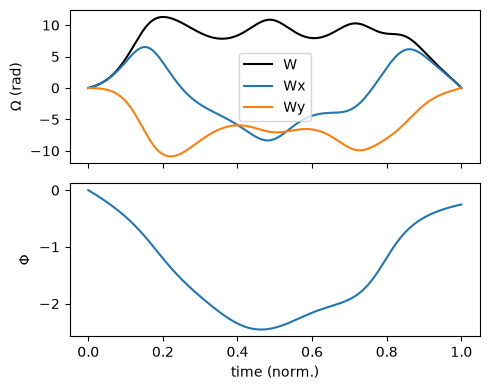

In [2]:
RESULTS_DIR = 'Results/Pulses'
PULSE_FILE  = 'pulse_fields_X_cfg0039.json'

files = sorted(glob.glob(os.path.join(RESULTS_DIR, '*.json')), key=os.path.getmtime)
print(f'{len(files)} file(s) found:\n')
for i, f in enumerate(files):
    print(f'[{i}]  {os.path.basename(f)}')

with open(os.path.join(RESULTS_DIR, PULSE_FILE)) as f:
    data = json.load(f)

print(f"\nFile:      {PULSE_FILE}")
print(f"source:    {data.get('source_pkl', 'N/A')}")
print(f"gate:      {data.get('gate', 'N/A')}")
print(f"n_points:  {data.get('n_points', 'N/A')}")

times = np.array(data['fields']['times'])
omega = np.array(data['fields']['omega'])
phi   = np.array(data['fields']['phi'])

Wx = omega * np.cos(phi)
Wy = omega * np.sin(phi)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(5, 4), sharex=True)
ax1.plot(times, omega, 'k', label='W')
ax1.plot(times, Wx, label='Wx')
ax1.plot(times, Wy, label='Wy')
ax1.set_ylabel(r'$\Omega$ (rad)')
ax1.legend()
ax2.plot(times, phi)
ax2.set_ylabel(r'$\Phi$')
ax2.set_xlabel('time (norm.)')
plt.tight_layout()
plt.show()


## Connect to IQM hardware

Everything from here on talks to a live server.


In [ ]:
# IQM_TOKEN must be set as an environment variable before running this notebook.
# Never hardcode a real token in a notebook cell, especially in a public repo.
#   export IQM_TOKEN="<your-api-token-here>"   # set this in your shell, before launching Jupyter
if 'IQM_TOKEN' not in os.environ:
    raise RuntimeError(
        "Set the IQM_TOKEN environment variable before running this notebook "
        "(e.g. `export IQM_TOKEN=<your-api-token-here>` in your shell before launching Jupyter). "
        "Never hardcode a token in a notebook cell, especially in a public repo."
    )

iqm_server_url = 'https://resonance.iqm.tech/emerald'   # <- change to your target machine

pulla = Pulla(iqm_server_url)
provider = IQMProvider(iqm_server_url)
backend = provider.get_backend()

print(f'Connected to {iqm_server_url}')


## Live qubit calibration

In [ ]:
expr_params = iqm_tools.get_qubit_params(iqm_server_url)
print('calibration_set_id:', expr_params.attrs['calibration_set_id'])
expr_params


## Match the pulse to a qubit + snap the gate duration to the hardware grid

Compares each live qubit's anharmonicity against the anharmonicity this pulse was
designed for (`design_anharmonicity_Tg_alpha` in the pulse-fields file -- the nominal
value from the config pkl's run_metadata) and snaps the implied gate duration to the
nearest 4 ns (the hardware grid: 4, 8, 12, ..., 36, 40, 44, ...).


In [ ]:
design_anharm = data.get('design_anharmonicity_Tg_alpha')
if design_anharm is None:
    raise ValueError("This pulse-fields file has no 'design_anharmonicity_Tg_alpha' -- "
                      "set Texp_ns and qbt manually instead of running this cell.")

anharm_GHz = expr_params['anharmonicity_MHz'].values / 1000  # MHz -> GHz
ratio = (design_anharm / (2 * np.pi)) / anharm_GHz

result = expr_params[['qubit']].copy()
result['anharmonicity_GHz'] = anharm_GHz
result['Te_ns'] = ratio

Te_ns = result['Te_ns'].values
Te_snapped = np.maximum(np.round(Te_ns / 4) * 4, 4)
result['Te_snapped'] = Te_snapped
result['dist_to_grid'] = np.abs(Te_ns - Te_snapped)

sorted_result = result.sort_values('dist_to_grid')
print(sorted_result[['qubit', 'Te_ns', 'Te_snapped', 'dist_to_grid']].to_string())


In [ ]:
qq = 0   # index into sorted_result -- 0 = best match

qbt   = sorted_result['qubit'].iloc[qq]
Texp  = sorted_result['Te_snapped'].iloc[qq]

print(f'qubit = {qbt},  Texp = {Texp} ns')


## Discretize the pulse for this qubit's gate duration

Resample onto the hardware's 0.5 ns sample grid and normalize to the
`max(|I|)^2 + max(|Q|)^2 <= 1` constraint.


In [ ]:
Wx_rhz = Wx / Texp   # rad/ns
Wy_rhz = Wy / Texp

N_samples = int(round(Texp / 0.5))
t_grid = np.linspace(0, 1, N_samples, endpoint=False)

Wx_hw = np.interp(t_grid, times, Wx_rhz)
Wy_hw = np.interp(t_grid, times, Wy_rhz)

max_norm = np.sqrt(np.max(np.abs(Wx_hw))**2 + np.max(np.abs(Wy_hw))**2)
i_samples = Wx_hw / max_norm
q_samples = Wy_hw / max_norm

print(f'N_samples = {N_samples},  Texp = {Texp} ns')
print(f'max(|I|)^2 + max(|Q|)^2 = {np.max(np.abs(i_samples))**2 + np.max(np.abs(q_samples))**2:.4f}  (must be <= 1)')

envelope = np.sqrt(i_samples**2 + q_samples**2)
fig, ax = plt.subplots(figsize=(5, 2.5))
ax.plot(envelope, 'k', label='envelope')
ax.plot(i_samples, 'o-', markersize=3, linewidth=0.5, label='I')
ax.plot(q_samples, 'o-', markersize=3, linewidth=0.5, label='Q')
ax.set_ylabel('normalized amplitude')
ax.set_xlabel('sample index')
ax.legend()
plt.tight_layout()
plt.show()


## Define a custom gate from the discretized samples

In [ ]:
_I_SAMPLES = i_samples.copy()
_Q_SAMPLES = q_samples.copy()
_N         = len(_I_SAMPLES)

@dataclass(frozen=True)
class DakisXWave_I(Waveform):
    def _sample(self, sample_coords: np.ndarray) -> np.ndarray:
        t_grid = np.linspace(0, 1, _N, endpoint=False)
        return np.interp(sample_coords + 0.5, t_grid, _I_SAMPLES,
                         left=_I_SAMPLES[0], right=_I_SAMPLES[-1])

@dataclass(frozen=True)
class DakisXWave_Q(Waveform):
    def _sample(self, sample_coords: np.ndarray) -> np.ndarray:
        t_grid = np.linspace(0, 1, _N, endpoint=False)
        return np.interp(sample_coords + 0.5, t_grid, _Q_SAMPLES,
                         left=_Q_SAMPLES[0], right=_Q_SAMPLES[-1])

# PRX_CustomWaveforms: general PRX gate calibrated as a single pi pulse (unlike the
# SX-specific class, no rz_before/rz_after -- see the notebook intro for why).
class DakisXGate(PRX_CustomWaveforms, wave_i=DakisXWave_I, wave_q=DakisXWave_Q):
    """Leakage-suppressed X (pi) gate."""
    pass

print(f'DakisXGate defined  |  max_i={np.max(np.abs(i_samples)):.5f}  max_q={np.max(np.abs(q_samples)):.5f}')


## Compiler setup

In [ ]:
compiler = get_qiskit_compiler(pulla, backend)
compiler.add_implementation("prx", "dakis_x", DakisXGate)

Delta_ghz = 0.0   # LO detuning offset -- refined in the frequency-sweep section below

def get_dakis_x_settings(circuits):
    s = compiler.get_settings(circuits=circuits)
    s.gate_definitions.prx.default_implementation = "dakis_x"
    s.gates.prx.dakis_x[qbt].set_from_dict({
        "duration":    Texp * 1e-9,
        "amplitude_i": amp_x,
        "amplitude_q": amp_x,
    })
    drive = s.controllers[qbt].drive
    drive.frequency = drive.frequency.value + Delta_ghz * 1e9
    return s

# Calibration circuit: single X -> P(|1>) ~= 1.0 at correct amplitude
qc = QuantumCircuit(1, 1)
qc.x(0)
qc.measure(0, 0)
qc.draw('mpl')


## Rabi amplitude calibration (3 rounds)

In [ ]:
def run_rabi_round(amp_center, amp_span, n_points, n_shots):
    A_values = np.clip(np.linspace(amp_center - amp_span, amp_center + amp_span, n_points), 0.0, 1.0)

    s = compiler.get_settings(circuits=[qc])
    s.gate_definitions.prx.default_implementation = "dakis_x"
    s.gates.prx.dakis_x[qbt].set_from_dict({
        "duration":    Texp * 1e-9,
        "amplitude_i": amp_center,
        "amplitude_q": amp_center,
    })
    drive = s.controllers[qbt].drive
    drive.frequency = drive.frequency.value + Delta_ghz * 1e9
    s.set_shots(n_shots)

    qs = s.gates.prx.dakis_x[qbt]
    amp_sweep = (
        Sweep(parameter=qs.amplitude_i.parameter, data=A_values),
        Sweep(parameter=qs.amplitude_q.parameter, data=A_values),
    )

    jd, ctx = compiler.compile(circuits=[qc], components=[qbt], settings=s, sweeps=[amp_sweep])
    job = pulla.submit_playlist(jd, context=ctx)
    job.wait_for_completion()

    if job.status != 'completed':
        print(f"Job failed: {job.status}")
        return None, None, None, None, None

    res  = job.result(compiler)
    prob_raw  = res.dataset["counter.result"].values[1]
    prob_corr = res.dataset[f'{qbt}__c_1_0_0_excited_state_probability'].values

    # target P(|1>) = 1.0 for a full X gate (vs 0.5 for SX -- see notebook intro)
    best_idx = np.argmin(np.abs(prob_raw - 1.0))
    best_A   = A_values[best_idx]
    print(f"  -> best A = {best_A:.5f}  (P(raw)={prob_raw[best_idx]:.4f}, P(corr)={prob_corr[best_idx]:.4f}, target=1.0)")
    return res, A_values, prob_raw, prob_corr, best_A


In [ ]:
# ── Round 1: wide scan ──────────────────────────────────────────────────────
# amp_center is a rough starting guess -- a full X pulse needs roughly double the
# amplitude of an SX pulse of the same duration/shape (same area, double the angle),
# so this starts from ~2x a typical calibrated SX amplitude. Adjust for your qubit.
print("Round 1")
res1, A1, P1, P1_corr, best1 = run_rabi_round(amp_center=0.30,
                                              amp_span  = 0.04,
                                              n_points  = 11,
                                              n_shots   = 500)
plt.plot(A1, P1)


In [ ]:
# ── Round 2: narrow scan around Round 1 peak ───────────────────────────────
print("Round 2")
res2, A2, P2, P2_corr, best2 = run_rabi_round(amp_center=best1,
                                              amp_span = 0.01,
                                              n_points = 11,
                                              n_shots  = 1000)


In [ ]:
# ── Round 3: fine scan around Round 2 peak ─────────────────────────────────
print("Round 3")
res3, A3, P3, P3_corr, best3 = run_rabi_round(amp_center=best2,
                                              amp_span  = 0.002,
                                              n_points  = 15,
                                              n_shots   = 2000)


In [ ]:
amp_x = best3
print(f"\nFinal X amplitude A = {amp_x:.5f}")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titles  = ['Round 1', 'Round 2', 'Round 3']
results = [(A1, P1, P1_corr, best1), (A2, P2, P2_corr, best2), (A3, P3, P3_corr, best3)]

for ax, (A, P, P_corr, best), title in zip(axes, results, titles):
    ax.plot(A, P, 'o-', label='raw')
    ax.plot(A, P_corr, 's-', label='corr')
    ax.axvline(best, color='tab:red', linestyle='--', label=f'A={best:.4f}')
    ax.axhline(1.0, linestyle=':', color='grey')
    ax.set_xlabel('amplitude A')
    ax.set_ylabel("P(|1>)  [X circuit]")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()


## Save the calibration

In [ ]:
from datetime import datetime

CAL_DIR = 'Results/Calibration'
os.makedirs(CAL_DIR, exist_ok=True)

machine  = iqm_server_url.rstrip('/').split('/')[-1]
ts       = datetime.now().strftime('%Y%m%d_%H%M%S')
stem     = f"scqc_x_{qbt}_{machine}_{ts}"

calib_path   = os.path.join(CAL_DIR, f"{stem}_calib.json")
samples_path = os.path.join(CAL_DIR, f"{stem}_samples.npz")

calib = {
    "source_pulse_file": PULSE_FILE,
    "samples_file":  os.path.basename(samples_path),
    "qubit":         qbt,
    "machine":       machine,
    "Texp_ns":       float(Texp),
    "Delta_ghz":     float(Delta_ghz),
    "amp_x":         float(amp_x),
    "amplitude_i":   float(amp_x),
    "amplitude_q":   float(amp_x),
    "peak_prob":     float(np.max(P3_corr)),
    "gate":          "x",
    "timestamp":     datetime.now().isoformat(),
}

with open(calib_path, "w") as f:
    json.dump(calib, f, indent=2)

np.savez(samples_path, i_samples=i_samples, q_samples=q_samples)

print(f"Saved: {calib_path}")
print(f"Saved: {samples_path}")
print(json.dumps(calib, indent=2))


## Sanity check: $X^2 = I$

In [ ]:
qc_x2 = QuantumCircuit(1, 1)
for _ in range(2):
    qc_x2.x(0)
qc_x2.measure(0, 0)

settings_x2 = get_dakis_x_settings([qc_x2])
settings_x2.controllers.options.playlist_repeats = 5000

jd, ctx = compiler.compile(circuits=[qc_x2], components=[qbt], settings=settings_x2)

job = pulla.submit_playlist(jd, context=ctx)
job.wait_for_completion()
res = job.result(compiler)

prob_x2 = res.dataset[f"{qbt}__c_1_0_0_excited_state_probability"].values.item()
print(f"X^2 excited state probability -- DakisXGate: {prob_x2:.4f}  (expected ~= 0)")


In [ ]:
# ── same circuit with the native IQM X gate, for comparison ────────────────
settings_native = compiler.get_settings(circuits=[qc_x2])
settings_native.controllers.options.playlist_repeats = 5000

jd_n, ctx_n = compiler.compile(circuits=[qc_x2], components=[qbt], settings=settings_native)

job_n = pulla.submit_playlist(jd_n, context=ctx_n)
job_n.wait_for_completion()
res_n = job_n.result(compiler)

prob_native = res_n.dataset[f"{qbt}__c_1_0_0_excited_state_probability"].values.item()

print(f"X^2  -- DakisXGate:  {prob_x2:.4f}")
print(f"X^2  -- native gate: {prob_native:.4f}")
print(f"difference:          {abs(prob_x2 - prob_native):.4f}")
